# Find which community influences our subtypes more

In [1]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap  
import shap  

In [3]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


# Doing random forest on partial transition

Use notebook: 'Analyse Cluster Backtrack.ipynb' for data

## Only making SHAP considering partial transitions [This is used in supplementary]

Getting only partial newtorks data

In [14]:
data_folder=Path('../../data/results/comm_umap_results/')
file_part=glob.glob(str(data_folder/'pca_part_df_*'))

original_data=[]

for f_part in file_part:
    
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    original_data.append(df_part.values)


Loading partial network labels

In [15]:
data=reader.data_read_pkl('raw/part_cluster_label.pkl')

Do random forest

In [18]:
X_list=original_data.copy()
y_list=data['label']



X_all = np.vstack(X_list)   
y_all = np.hstack(y_list)   

rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced")
rf.fit(X_all, y_all)

print("Global feature importances for partial transitions only:", rf.feature_importances_)



Global feature importances for partial transitions only: [0.09001596 0.1034002  0.19940535 0.18024685 0.17219799 0.13309168
 0.09217676 0.02946522]


In [19]:
comm=list(reader.data_read_bz2('results/comm_umap_results/pca_part_df_fn').columns)


Text(0.5, 1.0, 'Considering only Partial Transitions')

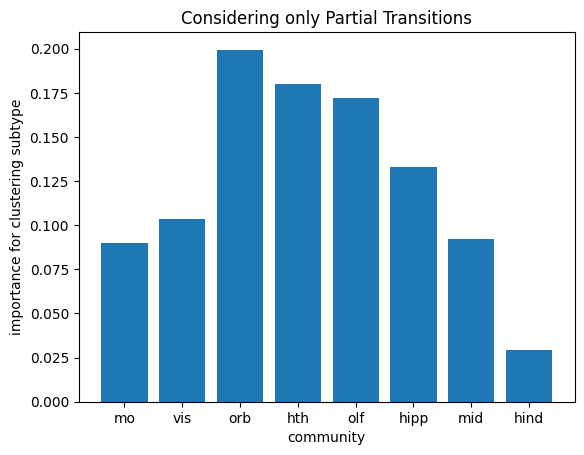

In [20]:
plt.bar(comm,rf.feature_importances_)
plt.xlabel('community')
plt.ylabel('importance for clustering subtype')
plt.title('Considering only Partial Transitions')

Supplementary figure 4.3

Global feature importances: [0.09001596 0.1034002  0.19940535 0.18024685 0.17219799 0.13309168
 0.09217676 0.02946522]
SHAP values shape: (1925, 8, 5)

Cluster-specific feature importance:
       Cluster_1  Cluster_2  Cluster_3  Cluster_4  Cluster_5
mo     0.040681   0.025374   0.021146   0.029153   0.054650
vis    0.052385   0.051578   0.029320   0.014214   0.083824
orb    0.099210   0.047131   0.071513   0.089188   0.067147
hth    0.104629   0.096325   0.061922   0.036614   0.057219
olf    0.082371   0.073617   0.029346   0.090610   0.047031
hipp   0.048414   0.044042   0.055176   0.036627   0.052833
mid    0.040851   0.032056   0.036079   0.015151   0.048570
hind   0.007264   0.013604   0.006249   0.000778   0.013226


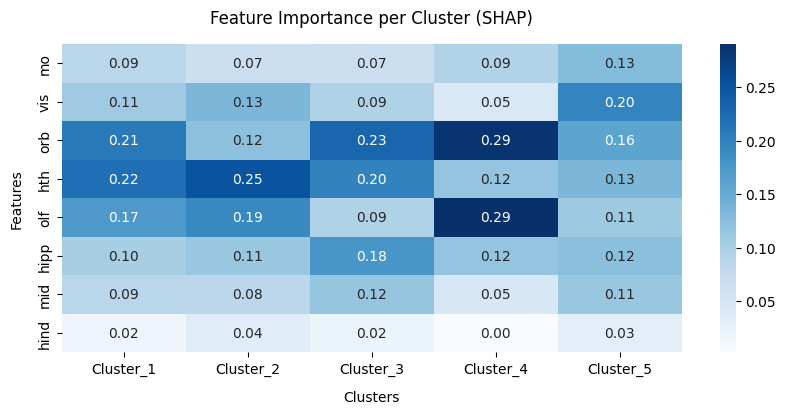


Top 2 features per cluster:
 {'Cluster_1': ['hth', 'orb'], 'Cluster_2': ['hth', 'olf'], 'Cluster_3': ['orb', 'hth'], 'Cluster_4': ['olf', 'orb'], 'Cluster_5': ['vis', 'orb']}


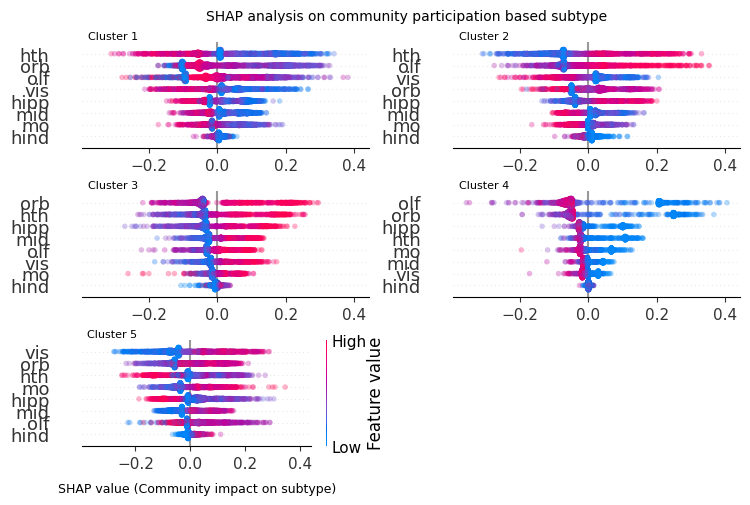

In [39]:
# Assuming feature_names, X_all, and y_all are already defined
feature_names = comm

# --- 1. Train Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced")
rf.fit(X_all, y_all)

print("Global feature importances:", rf.feature_importances_)

# --- 2. SHAP explainer ---
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_all)  
# Shape: (n_samples, n_features, n_classes)

print("SHAP values shape:", shap_values.shape)

# --- 3. Convert to per-cluster arrays ---
shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

# --- 4. Aggregate SHAP values per cluster (Mapped 1-5) ---
cluster_feature_importance = {}
for cluster_id, class_shap in enumerate(shap_values_list):
    mean_abs_shap = np.abs(class_shap).mean(axis=0)  # length = 8 features
    # Mapping cluster 0-4 to 1-5 here
    cluster_feature_importance[f"Cluster_{cluster_id + 1}"] = mean_abs_shap

importance_df = pd.DataFrame(cluster_feature_importance, index=feature_names)
print("\nCluster-specific feature importance:\n", importance_df)

# --- 5. Normalize per cluster for easier comparison ---
importance_norm = importance_df.div(importance_df.sum(axis=0), axis=1)

# --- 6. Heatmap visualization ---
plt.figure(figsize=(10, 4))
sns.heatmap(importance_norm, annot=True, cmap="Blues", fmt=".2f")
plt.title("Feature Importance per Cluster (SHAP)", pad=15)
plt.ylabel("Features", labelpad=10)
plt.xlabel("Clusters", labelpad=10)
plt.show()

# --- 7. Top 2 features per cluster ---
top_features = {}
for cluster in importance_df.columns:
    top_features[cluster] = importance_df[cluster].nlargest(2).index.tolist()

print("\nTop 2 features per cluster:\n", top_features)

# --- 8. Combined SHAP summary plots for each cluster (Shared X-axis & Compact Sizing) ---

# 1. Scale down global font settings for a tighter, cleaner profile
plt.rcParams.update({
    'font.size': 2,           # General text size
    'axes.labelsize': 9,       # Axis labels 
    'xtick.labelsize': 6,      # X-axis tick numbers
    'ytick.labelsize': 2       # Y-axis feature labels
})

# 2. Initialize the grid with shared X-axes and a smaller overall figure size (10x10)
fig, axes = plt.subplots(3, 2, figsize=(20,20), sharex=True) 
axes_flat = axes.flatten()

for i, class_shap in enumerate(shap_values_list):
    ax = axes_flat[i]  # Extract the single individual axes item!
    plt.sca(ax) 
    
    # Only show the feature value color bar on the very last subplot (Cluster 5, index 4)
    show_colorbar = (i == len(shap_values_list) - 1)
    
    # 3. Summary plot configuration
    shap.summary_plot(
        class_shap, 
        X_all, 
        feature_names=feature_names, 
        alpha=0.3,   
        show=False,
        color_bar=show_colorbar
    )
    
    # 4. FIX: Use 'ax' object instead of 'axes' matrix array
    ax.text(0.02, 1.1, f'Cluster {i + 1}', 
            transform=ax.transAxes, 
            fontsize=8, 
            va='top', 
            ha='left',
            zorder=5)
    
    # Changed index boundary from < 4 to < 3 so that index 3 (bottom of column 2) 
    # receives its needed X label.
    if i < 4:
        plt.xlabel("")
    else:
        plt.xlabel("SHAP value (Community impact on subtype)", fontsize=9, labelpad=8)

# Remove the unused 6th panel safely
if len(axes_flat) > len(shap_values_list):
    for j in range(len(shap_values_list), len(axes_flat)):
        fig.delaxes(axes_flat[j])

# 5. Clean layout rules protecting the single color bar from getting squished
plt.tight_layout(rect=[0, 0, 0.92, 1], h_pad=2.5, w_pad=4.5)
plt.suptitle("SHAP analysis on community participation based subtype",fontsize=10,y=1.04)
plt.show()

# Reset font properties back to default
plt.rcParams.update(plt.rcParamsDefault)